# Actividad individual 1: Clustering jerárquico y no jerárquico (K-Means)

**Base:** Base alumnos prepa.csv

**Objetivo:** encontrar grupos de alumnos según cómo califican a una universidad y comparar los dos métodos vistos en clase (Tarea 1: jerárquico aglomerativo, Tarea 2: K-Means).

**Preguntas:** ¿cuántos clusters se ven?, ¿qué características tienen?, ¿qué diferencia hay entre el jerárquico y el no jerárquico?, ¿qué universidades califican mejor?

## 1. Librerías y lectura de la base

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')

# La base tiene acentos y no abre con utf-8, por eso uso encoding='latin-1'
archivo = Path('Base alumnos prepa.csv')
alumnos = pd.read_csv(archivo, encoding='latin-1')
display(alumnos.head())

,ID_TEXT,ID_TEXT.1,CIUDAD,TIPO,UNIVERSIDAD_EVALUADA_NACIONAL,PRESTIGIO DE LA INSTITUCIÓN,NIVEL ACADÉMICO,OFERTA ACADÉMICA (CARRERAS OFERTADAS),PROFESORES,PROGRAMAS DE BECAS,COSTO DE COLEGIATURA Y OPCIONES DE PAGO,"INSTALACIONES, AULAS Y LABORATORIOS",PLAN DE ESTUDIOS,AMBIENTE ESTUDIANTIL,ACREDITACIONES Y CERTIFICACIONES,UBICACIÓN DEL CAMPUS,MODALIDADES HÍBRIDAS (PRESENCIAL Y ONLINE),MODALIDADES ONLINE,VALORES INSTITUCIONALES
0,Entrevistado_1,Entrevistado_1,AGUASCALIENTES,Primera mención,UVM,10.0,8.0,2.0,6.0,1.0,5.8,6.4,6.5,7.7,6.4,7.5,7.3,7.3,6.9
1,Entrevistado_2,Entrevistado_2,MORELIA,Primera mención,OTRAS1,7.0,8.0,8.0,8.0,6.4,4.0,5.0,6.5,7.7,6.4,7.5,7.3,7.3,6.9
2,Entrevistado_3,Entrevistado_3,MONTERREY,Primera mención,ITESM,10.0,5.0,5.0,8.0,8.0,10.0,6.4,6.5,7.7,6.4,7.5,7.3,7.3,6.9
3,Entrevistado_4,Entrevistado_4,GUADALAJARA,Primera mención,OTRAS1,8.0,6.0,6.0,9.0,6.4,4.0,6.4,6.5,7.7,6.4,7.5,7.3,7.3,6.9
4,Entrevistado_5,Entrevistado_5,CANCÚN,Primera mención,UNID,9.0,9.0,7.8,4.0,1.0,5.0,6.4,6.5,7.7,6.4,7.5,7.3,7.3,6.9


## 2. Exploración de los datos

In [2]:
# El comando shape nos permite inspeccionar la forma de los datos
alumnos.shape

(6000, 19)

In [3]:
# Nombres de las columnas
alumnos.columns

Index(['ID_TEXT', 'ID_TEXT.1', 'CIUDAD', 'TIPO',
       'UNIVERSIDAD_EVALUADA_NACIONAL', 'PRESTIGIO DE LA INSTITUCIÓN',
       'NIVEL ACADÉMICO', 'OFERTA ACADÉMICA (CARRERAS OFERTADAS)',
       'PROFESORES', 'PROGRAMAS DE BECAS',
       'COSTO DE COLEGIATURA Y OPCIONES DE PAGO',
       'INSTALACIONES, AULAS Y LABORATORIOS', 'PLAN DE ESTUDIOS',
       'AMBIENTE ESTUDIANTIL', 'ACREDITACIONES Y CERTIFICACIONES',
       'UBICACIÓN DEL CAMPUS', 'MODALIDADES HÍBRIDAS (PRESENCIAL Y ONLINE)',
       'MODALIDADES ONLINE', 'VALORES INSTITUCIONALES'],
      dtype='str')

In [4]:
# info nos da el tipo de dato y el conteo de valores no nulos
alumnos.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   ID_TEXT                                     6000 non-null   str    
 1   ID_TEXT.1                                   6000 non-null   str    
 2   CIUDAD                                      6000 non-null   str    
 3   TIPO                                        6000 non-null   str    
 4   UNIVERSIDAD_EVALUADA_NACIONAL               6000 non-null   str    
 5   PRESTIGIO DE LA INSTITUCIÓN                 6000 non-null   float64
 6   NIVEL ACADÉMICO                             6000 non-null   float64
 7   OFERTA ACADÉMICA (CARRERAS OFERTADAS)       6000 non-null   float64
 8   PROFESORES                                  6000 non-null   float64
 9   PROGRAMAS DE BECAS                          6000 non-null   float64
 10  COSTO DE COLEGIATURA Y 

In [5]:
# describe nos da los indicadores de las variables numéricas
alumnos.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PRESTIGIO DE LA INSTITUCIÓN,6000.0,8.25,1.60,1.0,8.0,8.4,9.0,10.0
NIVEL ACADÉMICO,6000.0,7.74,1.94,1.0,7.0,8.0,9.0,10.0
OFERTA ACADÉMICA (CARRERAS OFERTADAS),6000.0,7.29,2.23,1.0,7.0,7.8,8.0,10.0
PROFESORES,6000.0,7.78,1.78,1.0,8.0,8.0,8.0,10.0
PROGRAMAS DE BECAS,6000.0,6.37,2.35,1.0,6.4,6.4,7.0,10.0
COSTO DE COLEGIATURA Y OPCIONES DE PAGO,6000.0,6.11,2.30,1.0,5.8,5.8,7.0,10.0
"INSTALACIONES, AULAS Y LABORATORIOS",6000.0,6.51,1.67,1.0,6.4,6.4,6.4,10.0
PLAN DE ESTUDIOS,6000.0,6.67,1.41,1.0,6.5,6.5,6.5,10.0
AMBIENTE ESTUDIANTIL,6000.0,7.73,1.09,1.0,7.7,7.7,7.7,10.0
ACREDITACIONES Y CERTIFICACIONES,6000.0,6.45,1.34,1.0,6.4,6.4,6.4,10.0


In [6]:
# Cuántos valores distintos tiene cada variable categórica
for columna in ['CIUDAD', 'TIPO', 'UNIVERSIDAD_EVALUADA_NACIONAL']:
    print(columna, alumnos[columna].nunique())

CIUDAD 35
TIPO 1
UNIVERSIDAD_EVALUADA_NACIONAL 15


In [7]:
alumnos['UNIVERSIDAD_EVALUADA_NACIONAL'].value_counts()

UNIVERSIDAD_EVALUADA_NACIONAL
OTRAS1        2791
UAG            577
ITESM          502
UVM            453
TECMILENIO     195
UNIVA          195
LA SALLE       193
ITESO          189
UP             186
UNITEC         168
UNID           155
UNIVER         143
UAD            130
ANÁHUAC         99
U.MARISTA       24
Name: count, dtype: int64

In [8]:
alumnos['CIUDAD'].value_counts().head(10)

CIUDAD
GUADALAJARA         1281
MORELIA              559
VILLAHERMOSA         362
CULIACÁN             347
AGUASCALIENTES       319
CIUDAD DE MÉXICO     308
TEPIC                296
LEÓN                 279
TUXTLA GUTIÉRREZ     274
COATZACOALCOS        261
Name: count, dtype: int64

### Histograma de las 14 calificaciones

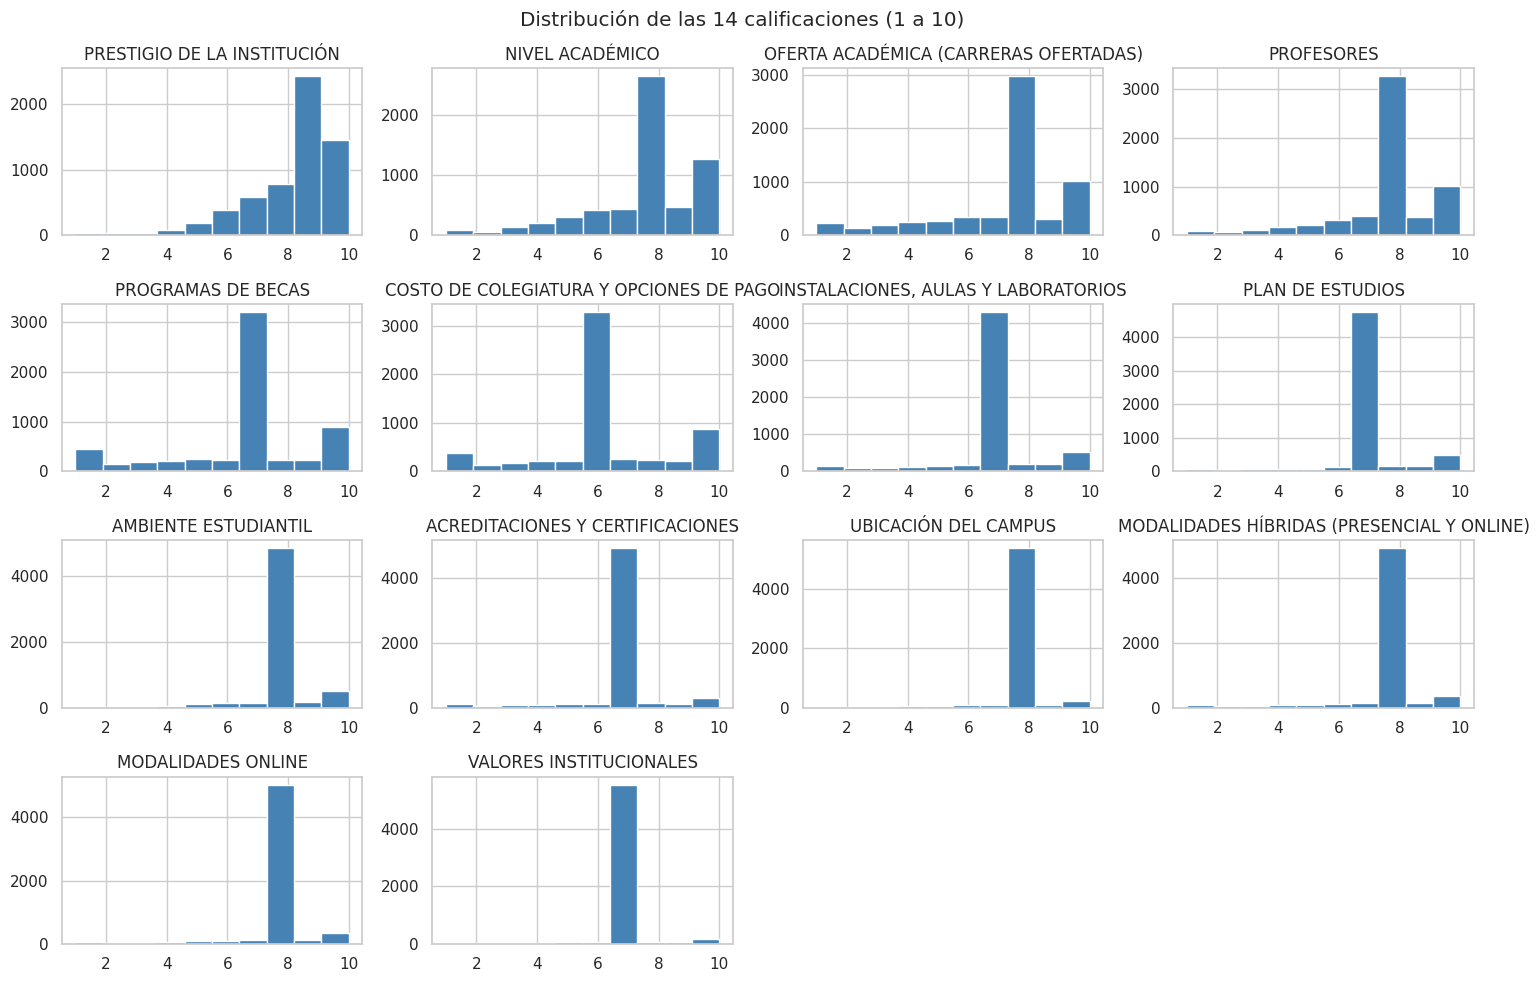

In [9]:
# Histograma de todas las calificaciones para ver cómo se distribuyen
alumnos.select_dtypes('number').hist(bins=10, figsize=(15, 10), layout=(4, 4), color='steelblue', edgecolor='white')
plt.suptitle('Distribución de las 14 calificaciones (1 a 10)')
plt.tight_layout()
plt.show()

**Observación:** en casi todas las variables hay una barra que sobresale mucho más que las demás. Lo reviso en la limpieza.

## 3. Limpieza de los datos

### 3.1 Columnas repetidas

In [10]:
# Comparo cada columna con las demás para ver si alguna es igual a otra
columnas_repetidas = []
for i, columna1 in enumerate(alumnos.columns):
    for columna2 in alumnos.columns[i + 1:]:
        if alumnos[columna1].equals(alumnos[columna2]):
            print(columna2, 'es igual a', columna1)
            columnas_repetidas.append(columna2)

print('Columnas repetidas:', columnas_repetidas)

ID_TEXT.1 es igual a ID_TEXT
Columnas repetidas: ['ID_TEXT.1']


### 3.2 Columnas con un solo valor

In [11]:
# Una columna que tiene el mismo valor en todos los alumnos no sirve para distinguirlos
columnas_constantes = []
for columna in alumnos.columns:
    if alumnos[columna].nunique() == 1:
        print(columna, 'solo tiene el valor:', alumnos[columna].unique()[0])
        columnas_constantes.append(columna)

print('Columnas con un solo valor:', columnas_constantes)

TIPO solo tiene el valor: Primera mención
Columnas con un solo valor: ['TIPO']


In [12]:
# Elimino las columnas que encontré
alumnos_limpio = alumnos.drop(columns=columnas_repetidas + columnas_constantes)
print('Columnas eliminadas:', columnas_repetidas + columnas_constantes)
alumnos_limpio.shape

Columnas eliminadas: ['ID_TEXT.1', 'TIPO']


(6000, 17)

### 3.3 Filas duplicadas

In [13]:
# Duplicados contando todas las columnas
print('Filas duplicadas:', alumnos_limpio.duplicated().sum())

# Duplicados sin contar el ID (mismo alumno con distinto número)
print('Filas duplicadas sin el ID:', alumnos_limpio.drop(columns='ID_TEXT').duplicated().sum())

Filas duplicadas: 0
Filas duplicadas sin el ID: 0


### 3.4 Valores faltantes

In [14]:
# Valores faltantes por columna
alumnos_limpio.isna().sum()

ID_TEXT                                       0
CIUDAD                                        0
UNIVERSIDAD_EVALUADA_NACIONAL                 0
PRESTIGIO DE LA INSTITUCIÓN                   0
NIVEL ACADÉMICO                               0
OFERTA ACADÉMICA (CARRERAS OFERTADAS)         0
PROFESORES                                    0
PROGRAMAS DE BECAS                            0
COSTO DE COLEGIATURA Y OPCIONES DE PAGO       0
INSTALACIONES, AULAS Y LABORATORIOS           0
PLAN DE ESTUDIOS                              0
AMBIENTE ESTUDIANTIL                          0
ACREDITACIONES Y CERTIFICACIONES              0
UBICACIÓN DEL CAMPUS                          0
MODALIDADES HÍBRIDAS (PRESENCIAL Y ONLINE)    0
MODALIDADES ONLINE                            0
VALORES INSTITUCIONALES                       0
dtype: int64

### 3.5 Valores que se repiten demasiado

In [15]:
# En los histogramas vi una barra muy alta. Busco cuál es el valor más frecuente de cada calificación
calificaciones = alumnos_limpio.select_dtypes('number').columns

for columna in calificaciones:
    conteo = alumnos_limpio[columna].value_counts()
    print(f'{columna}: el valor {conteo.index[0]} aparece {conteo.iloc[0]} veces')

PRESTIGIO DE LA INSTITUCIÓN: el valor 8.4 aparece 1663 veces
NIVEL ACADÉMICO: el valor 8.0 aparece 2656 veces
OFERTA ACADÉMICA (CARRERAS OFERTADAS): el valor 7.8 aparece 2633 veces
PROFESORES: el valor 8.0 aparece 3282 veces
PROGRAMAS DE BECAS: el valor 6.4 aparece 2936 veces
COSTO DE COLEGIATURA Y OPCIONES DE PAGO: el valor 5.8 aparece 3092 veces
INSTALACIONES, AULAS Y LABORATORIOS: el valor 6.4 aparece 4129 veces
PLAN DE ESTUDIOS: el valor 6.5 aparece 4594 veces
AMBIENTE ESTUDIANTIL: el valor 7.7 aparece 4684 veces
ACREDITACIONES Y CERTIFICACIONES: el valor 6.4 aparece 4769 veces
UBICACIÓN DEL CAMPUS: el valor 7.5 aparece 5295 veces
MODALIDADES HÍBRIDAS (PRESENCIAL Y ONLINE): el valor 7.3 aparece 4767 veces
MODALIDADES ONLINE: el valor 7.3 aparece 4889 veces
VALORES INSTITUCIONALES: el valor 6.9 aparece 5484 veces


In [16]:
# Varios de los valores más repetidos tienen decimales (8.4, 7.8, 6.4...), aunque las respuestas normales son enteras.
# Reviso cuántas calificaciones de cada alumno tienen ese valor repetido
valor_repetido = alumnos_limpio[calificaciones].mode().iloc[0]
repetidos_por_alumno = (alumnos_limpio[calificaciones] == valor_repetido).sum(axis=1)
repetidos_por_alumno.value_counts().sort_index()

9     5154
10     819
11      27
Name: count, dtype: int64

Todos los alumnos tienen entre 9 y 11 calificaciones con el valor repetido. Parece que cada alumno contestó solo algunas y las demás se **rellenaron con un promedio**.

In [17]:
# Porcentaje de relleno en cada calificación
relleno = pd.DataFrame({
    'valor_repetido': valor_repetido,
    'pct_relleno': (alumnos_limpio[calificaciones] == valor_repetido).mean() * 100
}).sort_values('pct_relleno').round(1)
relleno

,valor_repetido,pct_relleno
PRESTIGIO DE LA INSTITUCIÓN,8.4,27.7
OFERTA ACADÉMICA (CARRERAS OFERTADAS),7.8,43.9
NIVEL ACADÉMICO,8.0,44.3
PROGRAMAS DE BECAS,6.4,48.9
COSTO DE COLEGIATURA Y OPCIONES DE PAGO,5.8,51.5
PROFESORES,8.0,54.7
"INSTALACIONES, AULAS Y LABORATORIOS",6.4,68.8
PLAN DE ESTUDIOS,6.5,76.6
AMBIENTE ESTUDIANTIL,7.7,78.1
MODALIDADES HÍBRIDAS (PRESENCIAL Y ONLINE),7.3,79.4


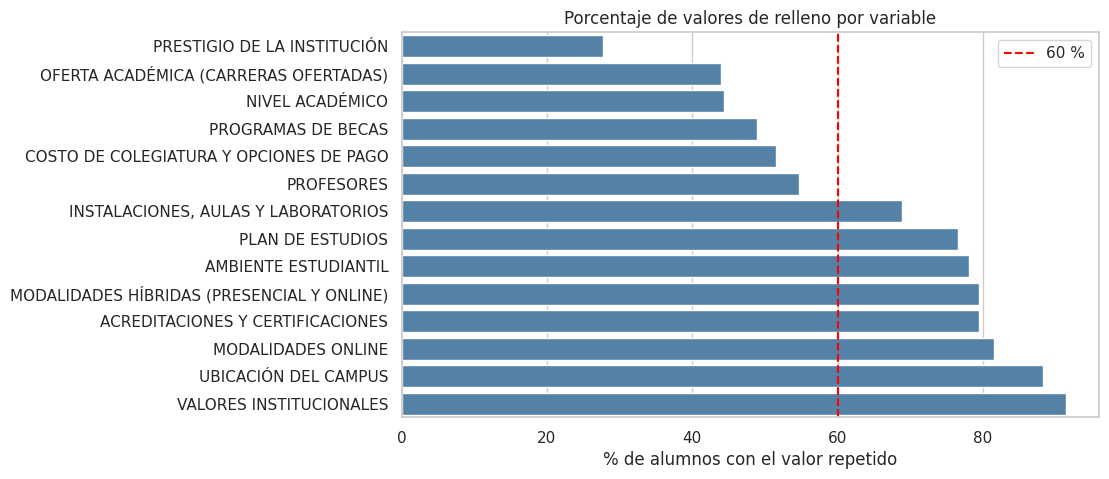

In [18]:
plt.figure(figsize=(9, 5))
sns.barplot(x=relleno['pct_relleno'], y=relleno.index, color='steelblue')
plt.axvline(60, color='red', linestyle='--', label='60 %')
plt.title('Porcentaje de valores de relleno por variable')
plt.xlabel('% de alumnos con el valor repetido')
plt.ylabel('')
plt.legend()
plt.show()

**Decisiones de limpieza:**
- Quité las columnas repetidas y las que tienen un solo valor.
- No hay duplicados ni faltantes, así que no tuve que borrar filas.
- No borré los valores de relleno porque todos los alumnos tienen varios y me quedaría sin datos. Los uso para escoger variables.

## 4. Selección de variables

Me quedo con las variables que tienen **menos de 60 % de relleno**. En las demás casi todos los alumnos tienen el mismo número, y los grupos se formarían alrededor de ese valor y no de lo que opinan los alumnos.

En clase se mencionó que se toman 5 variables, pues es lo que usualmente se hace en campo o en la vida real, pero se tomaron 6 porque son las únicas que pasan el criterio de menos de 60 % de relleno, no están correlacionadas entre sí (ninguna repite información de otra) y cubren las dos partes de la decisión: la académica (prestigio, nivel académico, oferta y profesores) y la económica (becas y costo). Si quitaba una, sería una decisión sin un criterio. En la sección 8.6 compruebo qué pasa con 5 variables.

In [19]:
# Variables que pasan el criterio de menos de 60 % de relleno
seleccion = relleno[relleno['pct_relleno'] < 60].index.tolist()
print('Variables seleccionadas:', seleccion)

Variables seleccionadas: ['PRESTIGIO DE LA INSTITUCIÓN', 'OFERTA ACADÉMICA (CARRERAS OFERTADAS)', 'NIVEL ACADÉMICO', 'PROGRAMAS DE BECAS', 'COSTO DE COLEGIATURA Y OPCIONES DE PAGO', 'PROFESORES']


In [20]:
# Les pongo nombres cortos para que las gráficas se lean mejor
nombres_cortos = {
    'PRESTIGIO DE LA INSTITUCIÓN': 'Prestigio',
    'NIVEL ACADÉMICO': 'Nivel académico',
    'OFERTA ACADÉMICA (CARRERAS OFERTADAS)': 'Oferta académica',
    'PROFESORES': 'Profesores',
    'PROGRAMAS DE BECAS': 'Becas',
    'COSTO DE COLEGIATURA Y OPCIONES DE PAGO': 'Costo y pagos'
}
datos = alumnos_limpio.rename(columns=nombres_cortos)
variables = [nombres_cortos[c] for c in nombres_cortos if c in seleccion]

X = datos[variables].copy()
X.head()

,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
0,10.0,8.0,2.0,6.0,1.0,5.8
1,7.0,8.0,8.0,8.0,6.4,4.0
2,10.0,5.0,5.0,8.0,8.0,10.0
3,8.0,6.0,6.0,9.0,6.4,4.0
4,9.0,9.0,7.8,4.0,1.0,5.0


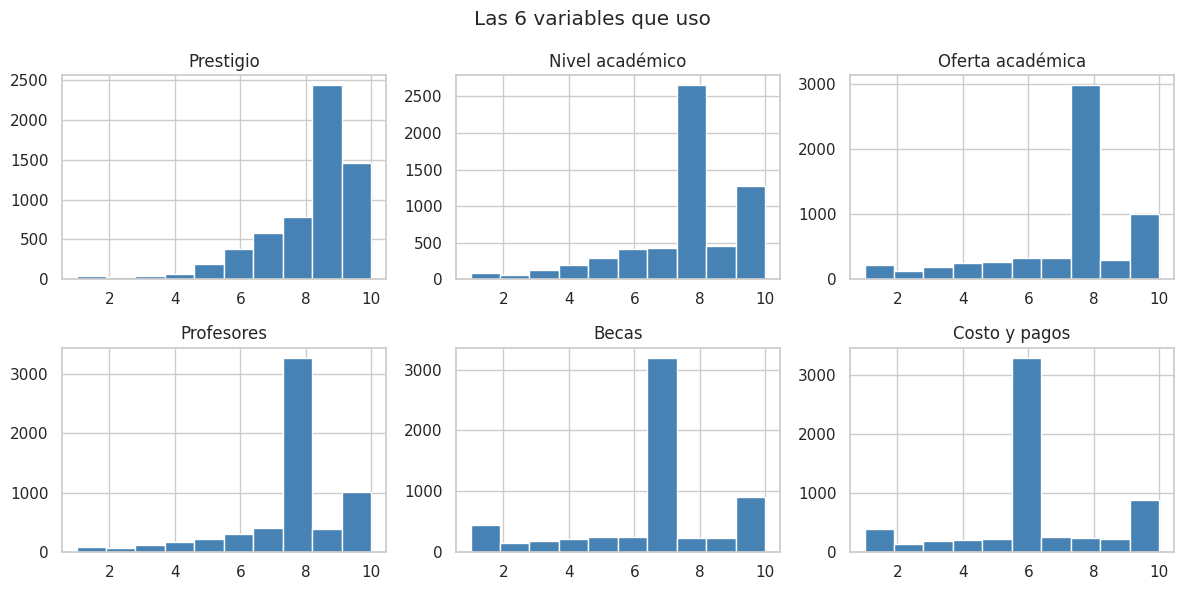

In [21]:
X.hist(bins=10, figsize=(12, 6), layout=(2, 3), color='steelblue', edgecolor='white')
plt.suptitle('Las 6 variables que uso')
plt.tight_layout()
plt.show()

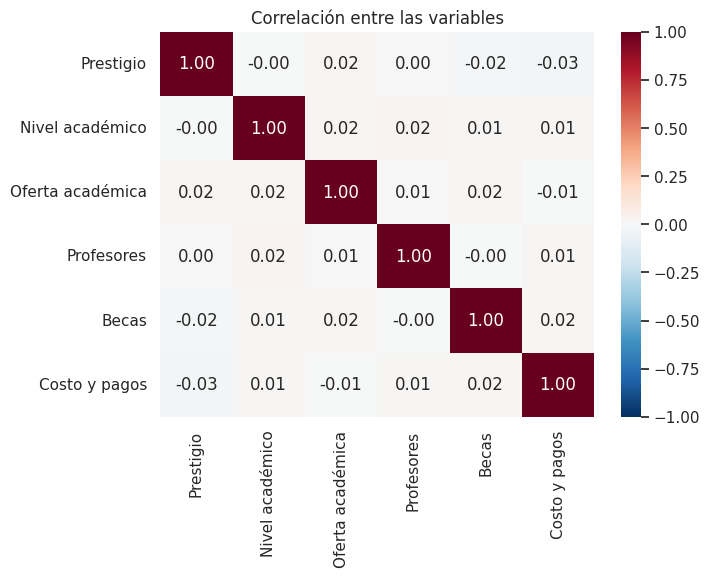

In [22]:
# Reviso que las variables no estén correlacionadas
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlación entre las variables')
plt.show()

## 5. ¿Normalizar o estandarizar?

- En clase vimos que estandarizar compara **cuánto se aleja un valor del promedio** y Min-Max compara **dónde está dentro del rango**.
- También vimos que **para clustering se recomienda empezar con estandarización**.
- Mis 6 variables ya van de 1 a 10, entonces normalizar casi no cambia nada. Lo que cambia entre ellas es qué tan dispersas están.

Lo compruebo comparando la desviación estándar con cada opción:

In [23]:
# Min-Max con la fórmula de clase: (valor - mínimo) / (máximo - mínimo)
X_minmax = (X - X.min()) / (X.max() - X.min())

comparacion = pd.DataFrame({
    'Desv. original': X.std(),
    'Desv. Min-Max': X_minmax.std(),
    'Desv. estandarizada': pd.DataFrame(StandardScaler().fit_transform(X), columns=variables).std()
}).round(3)
comparacion

,Desv. original,Desv. Min-Max,Desv. estandarizada
Prestigio,1.602,0.178,1.0
Nivel académico,1.944,0.216,1.0
Oferta académica,2.226,0.247,1.0
Profesores,1.778,0.198,1.0
Becas,2.354,0.262,1.0
Costo y pagos,2.297,0.255,1.0


Con Min-Max, Becas sigue pesando casi 50 % más que Prestigio. Con la estandarización todas quedan en 1, así que todas cuentan igual en la distancia. **Decisión: estandarizar.**

In [24]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Reviso que la media quede en 0 y la desviación en 1
pd.DataFrame(X_escalado, columns=variables).agg(['mean', 'std']).round(2)

,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
mean,-0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Los alumnos antes de hacer clusters

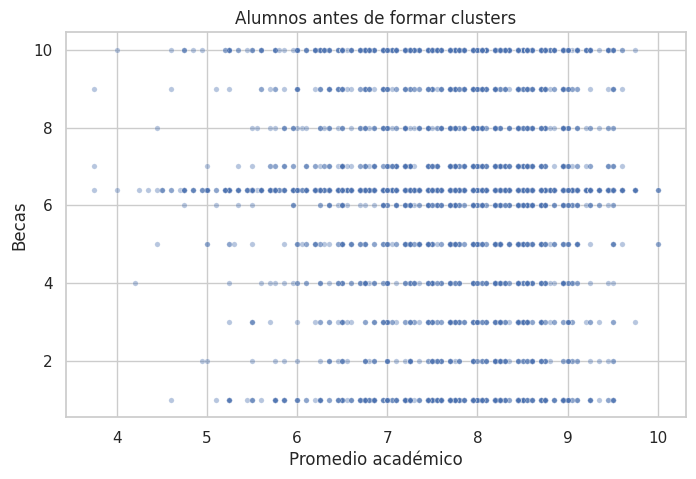

In [25]:
# Son 6 variables y la gráfica solo tiene 2 ejes.
# Junto las 4 académicas en un promedio y lo grafico contra Becas
academicas = ['Prestigio', 'Nivel académico', 'Oferta académica', 'Profesores']
datos['Promedio académico'] = datos[academicas].mean(axis=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=datos, x='Promedio académico', y='Becas', s=15, alpha=0.4)
plt.title('Alumnos antes de formar clusters')
plt.show()

### Misma gráfica con los puntos dispersos

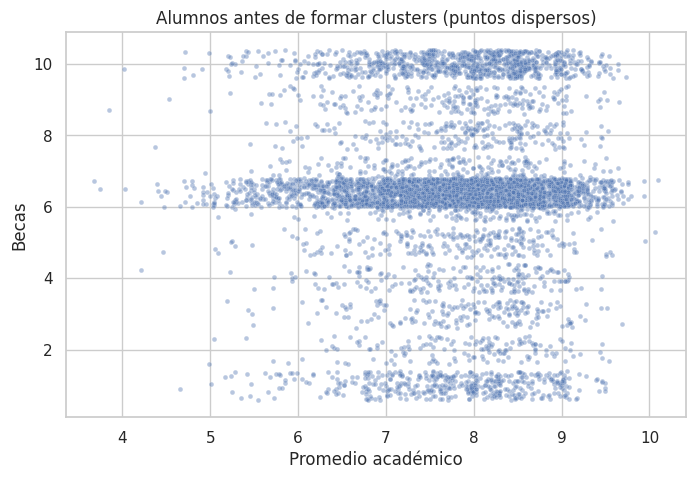

In [26]:
# Becas solo tiene valores enteros (y el 6.4 de relleno), por eso los puntos salen en líneas.
# Les sumo un desplazamiento pequeño solo para la gráfica, para que se vean dispersos
n = len(datos)
puntos_antes = datos[['Promedio académico', 'Becas']].copy()
desplazamiento_x = pd.Series(range(n)).sample(frac=1, random_state=10).values / n - 0.5
desplazamiento_y = pd.Series(range(n)).sample(frac=1, random_state=20).values / n - 0.5
puntos_antes['Promedio académico'] = puntos_antes['Promedio académico'] + desplazamiento_x * 0.2
puntos_antes['Becas'] = puntos_antes['Becas'] + desplazamiento_y * 0.8

plt.figure(figsize=(8, 5))
sns.scatterplot(data=puntos_antes, x='Promedio académico', y='Becas', s=12, alpha=0.4)
plt.title('Alumnos antes de formar clusters (puntos dispersos)')
plt.show()

A simple vista no se ven grupos claros, por eso uso el dendrograma, el codo y la silueta para decidir cuántos hay.

## 7. Clustering jerárquico aglomerativo (Tarea 1)

### 7.1 Dendrograma

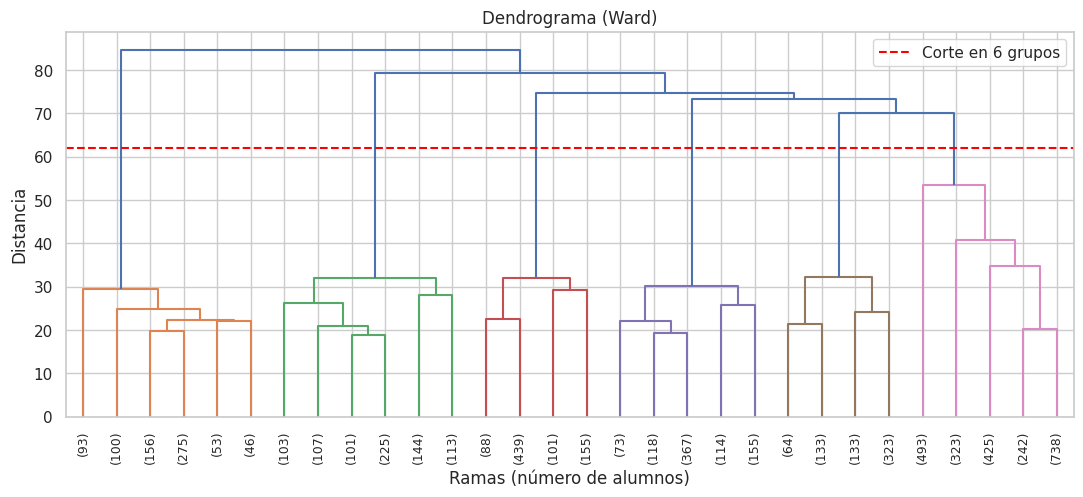

In [27]:
# Para dibujar el dendrograma se usa scipy
from scipy.cluster.hierarchy import linkage, dendrogram

# linkage arma el árbol con el método de Ward
matriz_ward = linkage(X_escalado, method='ward')

# Solo muestro las últimas 30 uniones porque con 6000 alumnos no se lee
plt.figure(figsize=(13, 5))
dendrogram(matriz_ward, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, color_threshold=62)
plt.axhline(62, color='red', linestyle='--', label='Corte en 6 grupos')
plt.title('Dendrograma (Ward)')
plt.xlabel('Ramas (número de alumnos)')
plt.ylabel('Distancia')
plt.legend()
plt.show()

In [28]:
# Alturas de las últimas uniones, para ver dónde está el salto más grande
alturas = pd.Series(matriz_ward[-10:, 2][::-1])
saltos = pd.DataFrame({'Grupos': range(2, 11),
                       'Altura': alturas[:9].values,
                       'Salto': (alturas[:9].values - alturas[1:].values)}).round(1)
saltos

,Grupos,Altura,Salto
0,2,84.6,5.3
1,3,79.3,4.6
2,4,74.8,1.4
3,5,73.4,3.2
4,6,70.1,16.7
5,7,53.5,12.7
6,8,40.8,6.1
7,9,34.8,2.5
8,10,32.3,0.3


El salto más grande (16.7) deja **6 grupos**.

### 7.2 Silueta para distintos números de grupos

In [29]:
# Igual que en la Tarea 1
from sklearn.cluster import AgglomerativeClustering

silueta_ward = []
for k in range(2, 9):
    modelo = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    etiquetas = modelo.fit_predict(X_escalado)
    silueta_ward.append(silhouette_score(X_escalado, etiquetas))

pd.DataFrame({'K': range(2, 9), 'Silueta Ward': silueta_ward}).round(3)

,K,Silueta Ward
0,2,0.187
1,3,0.154
2,4,0.152
3,5,0.161
4,6,0.165
5,7,0.133
6,8,0.121


La silueta más alta después de K = 2 es K = 6. Con K = 2 solo se separaría un grupo del resto. Coincide con el dendrograma: **6 grupos**.

### 7.3 Modelo con 6 grupos

In [30]:
clustering_model = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
clustering_model.fit(X_escalado)
data_labels = clustering_model.labels_

print('Silueta:', round(silhouette_score(X_escalado, data_labels), 3))
pd.Series(data_labels).value_counts().sort_index()

Silueta: 0.165


0    2221
1     783
2     653
3     723
4     827
5     793
Name: count, dtype: int64

### 7.4 Perfil de cada grupo

In [31]:
# Promedio de cada grupo en la escala estandarizada (0 = promedio de todos)
perfil_ward = pd.DataFrame(X_escalado, columns=variables).groupby(data_labels).mean()
perfil_ward.round(2)

,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
0,0.39,0.44,0.44,0.35,0.37,-0.06
1,0.19,-1.70,0.02,0.29,0.24,0.04
2,-1.78,0.17,0.40,0.20,0.32,0.22
3,0.08,-0.02,0.06,-2.08,0.08,-0.08
4,0.02,0.30,-1.61,0.22,0.24,0.03
5,0.09,0.01,0.05,0.25,-1.84,-0.02


In [32]:
# Le pongo nombre a cada grupo según la variable que califica más bajo
nombres_ward = {}
for grupo in perfil_ward.index:
    if perfil_ward.loc[grupo].min() < -1:
        nombres_ward[grupo] = 'Críticos de ' + perfil_ward.loc[grupo].idxmin().lower()
    else:
        nombres_ward[grupo] = 'Satisfechos en general'
nombres_ward

{0: 'Satisfechos en general',
 1: 'Críticos de nivel académico',
 2: 'Críticos de prestigio',
 3: 'Críticos de profesores',
 4: 'Críticos de oferta académica',
 5: 'Críticos de becas'}

In [33]:
cluster_results = datos.copy()
cluster_results['Grupo Ward'] = pd.Series(data_labels).map(nombres_ward)

# Orden y colores que voy a usar en todas las gráficas
orden = cluster_results['Grupo Ward'].value_counts().index.tolist()
colores = dict(zip(orden, sns.color_palette('bright', 6)))

perfil_tabla_ward = cluster_results.groupby('Grupo Ward')[variables].mean().loc[orden]
perfil_tabla_ward.insert(0, 'Alumnos', cluster_results['Grupo Ward'].value_counts())
perfil_tabla_ward.round(2)

,Alumnos,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
Grupo Ward,,,,,,,
Satisfechos en general,2221,8.88,8.60,8.25,8.40,7.23,5.98
Críticos de oferta académica,827,8.29,8.33,3.70,8.17,6.93,6.17
Críticos de becas,793,8.39,7.76,7.39,8.22,2.03,6.07
Críticos de nivel académico,783,8.55,4.44,7.34,8.30,6.92,6.19
Críticos de profesores,723,8.37,7.70,7.42,4.08,6.56,5.93
Críticos de prestigio,653,5.41,8.06,8.18,8.13,7.11,6.62


### 7.5 Gráficas del jerárquico

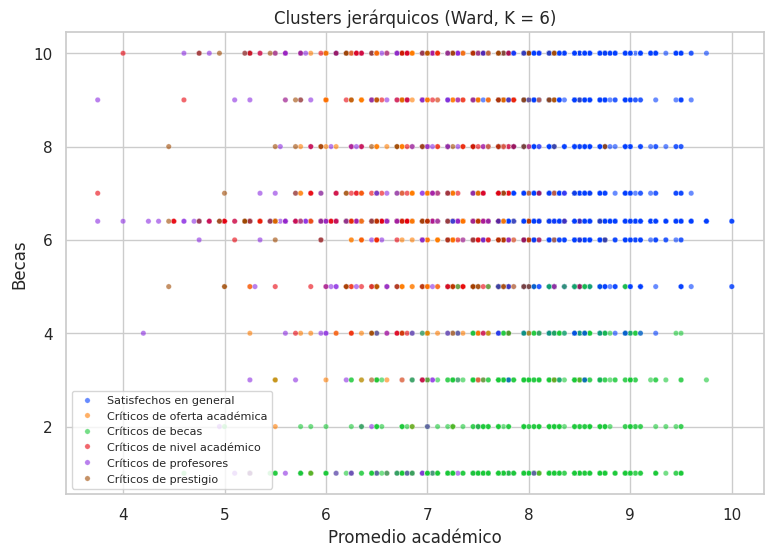

In [34]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=cluster_results, x='Promedio académico', y='Becas', hue='Grupo Ward',
                hue_order=orden, palette=colores, s=15, alpha=0.6)
plt.title('Clusters jerárquicos (Ward, K = 6)')
plt.legend(fontsize=8)
plt.show()

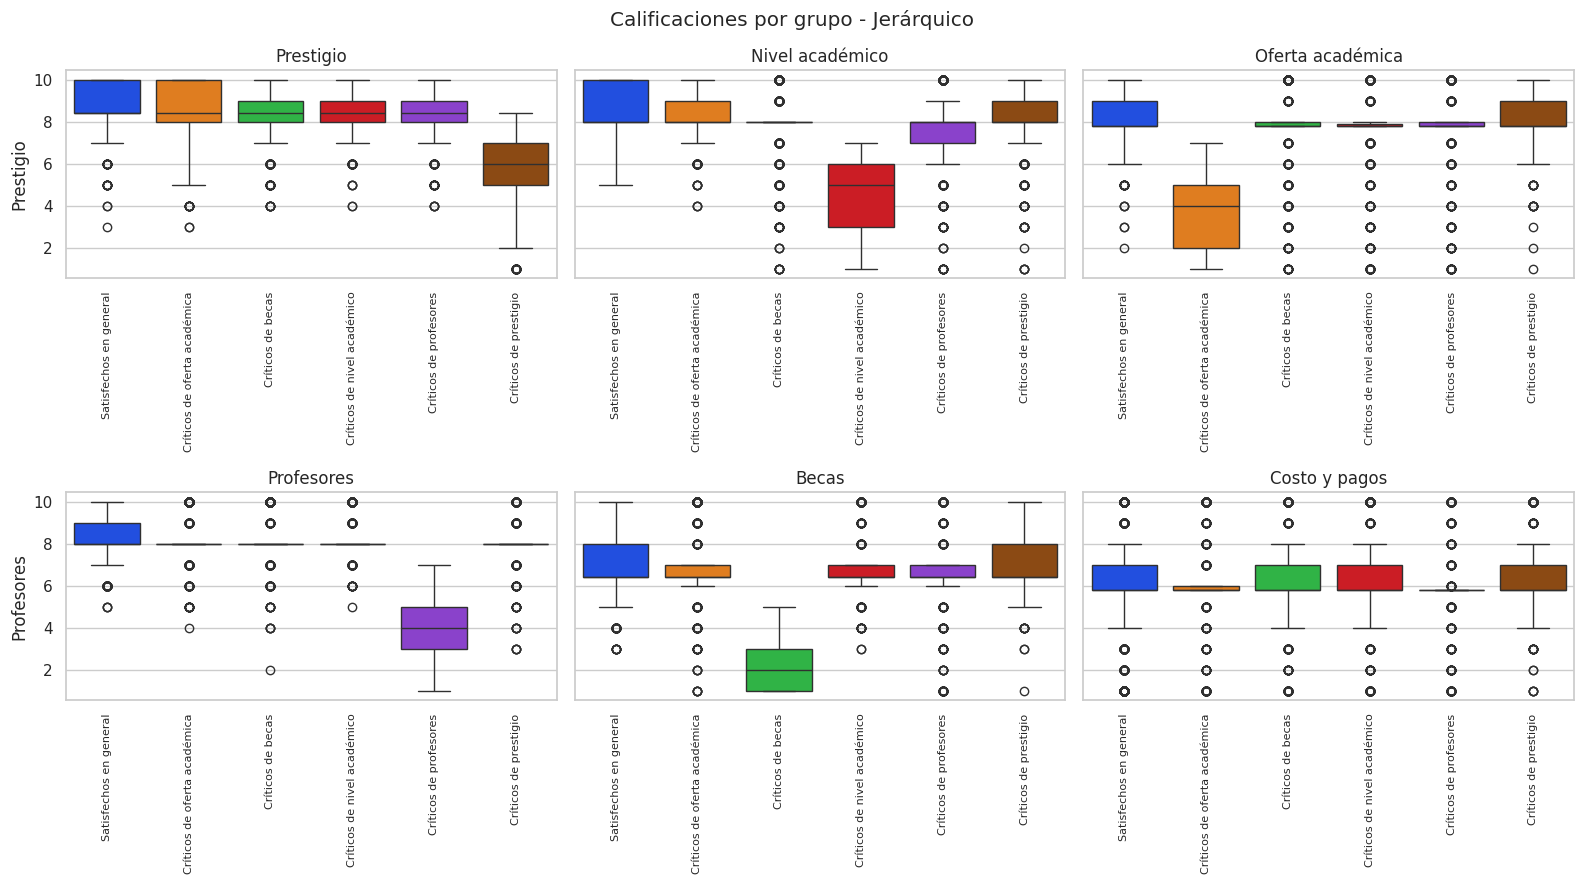

In [35]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for eje, variable in zip(ejes.flat, variables):
    sns.boxplot(data=cluster_results, x='Grupo Ward', y=variable, order=orden,
                hue='Grupo Ward', palette=colores, legend=False, ax=eje)
    eje.set_title(variable)
    eje.set_xlabel('')
    eje.tick_params(axis='x', rotation=90, labelsize=8)
plt.suptitle('Calificaciones por grupo - Jerárquico')
plt.tight_layout()
plt.show()

### 7.6 Revisar un grupo

In [36]:
# Filtro un grupo como en la Tarea 1
grupo_profesores = cluster_results.loc[cluster_results['Grupo Ward'] == 'Críticos de profesores']
print('Alumnos:', len(grupo_profesores))
grupo_profesores[variables].describe().round(2)

Alumnos: 723


,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
count,723.00,723.00,723.00,723.00,723.00,723.00
mean,8.37,7.70,7.42,4.08,6.56,5.93
std,1.18,1.78,2.09,1.67,2.08,2.17
min,4.00,1.00,1.00,1.00,1.00,1.00
25%,8.00,7.00,7.80,3.00,6.40,5.80
50%,8.40,8.00,7.80,4.00,6.40,5.80
75%,9.00,8.00,8.00,5.00,7.00,5.80
max,10.00,10.00,10.00,7.00,10.00,10.00


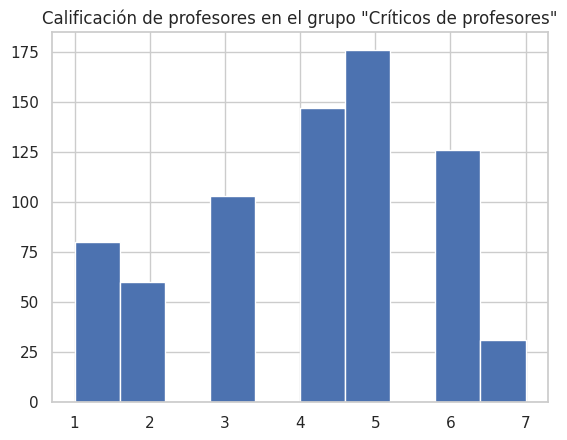

In [37]:
grupo_profesores['Profesores'].hist()
plt.title('Calificación de profesores en el grupo "Críticos de profesores"')
plt.show()

## 8. Clustering no jerárquico: K-Means (Tarea 2)

### 8.1 Método del codo y silueta

In [38]:
resultados_k = []
for k in range(2, 9):
    modelo_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_prueba = modelo_prueba.fit_predict(X_escalado)
    resultados_k.append({
        'K': k,
        'Inercia': modelo_prueba.inertia_,
        'Silueta K-Means': silhouette_score(X_escalado, etiquetas_prueba),
        'Grupo más pequeño': pd.Series(etiquetas_prueba).value_counts().min()
    })

tabla_k = pd.DataFrame(resultados_k)
tabla_k['Silueta Ward'] = silueta_ward
tabla_k.round(3)

,K,Inercia,Silueta K-Means,Grupo más pequeño,Silueta Ward
0,2,31654.683,0.198,1054,0.187
1,3,28071.145,0.181,992,0.154
2,4,25166.818,0.165,756,0.152
3,5,22315.289,0.183,693,0.161
4,6,19785.070,0.209,558,0.165
5,7,17735.769,0.209,500,0.133
6,8,16617.300,0.206,474,0.121


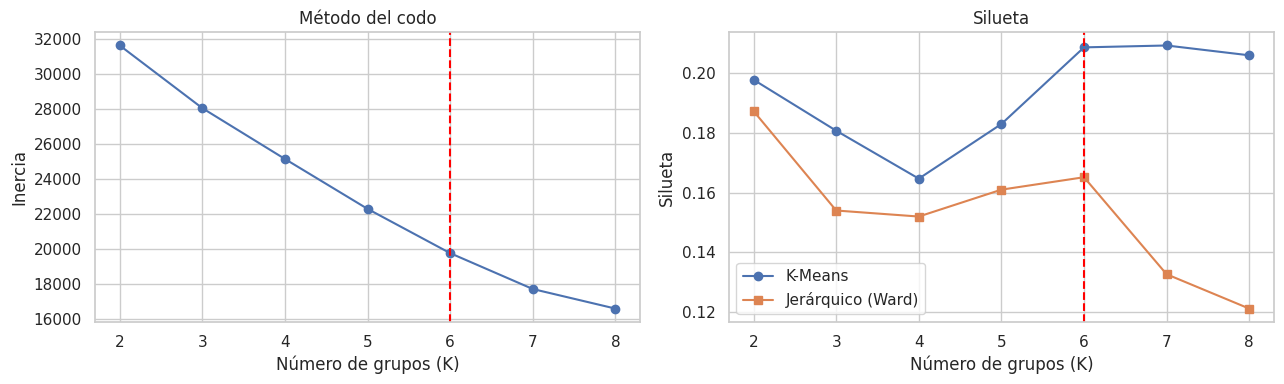

In [39]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].plot(tabla_k['K'], tabla_k['Inercia'], marker='o')
ejes[0].axvline(6, color='red', linestyle='--')
ejes[0].set(title='Método del codo', xlabel='Número de grupos (K)', ylabel='Inercia')
ejes[1].plot(tabla_k['K'], tabla_k['Silueta K-Means'], marker='o', label='K-Means')
ejes[1].plot(tabla_k['K'], tabla_k['Silueta Ward'], marker='s', label='Jerárquico (Ward)')
ejes[1].axvline(6, color='red', linestyle='--')
ejes[1].set(title='Silueta', xlabel='Número de grupos (K)', ylabel='Silueta')
ejes[1].legend()
plt.tight_layout()
plt.show()

La silueta más alta de K-Means es en K = 6 y en el codo la inercia deja de bajar tanto después de 6. Coincide con el dendrograma. **Uso K = 6.**

### 8.2 Modelo con 6 grupos y centroides

In [40]:
modelo_km = KMeans(n_clusters=6, random_state=42, n_init=10)
etiquetas_km = modelo_km.fit_predict(X_escalado)

print('Inercia:', round(modelo_km.inertia_, 2))
print('Silueta:', round(silhouette_score(X_escalado, etiquetas_km), 3))

Inercia: 19785.07


Silueta: 0.209


In [41]:
# Mismo criterio de nombres que en el jerárquico
perfil_km = pd.DataFrame(X_escalado, columns=variables).groupby(etiquetas_km).mean()
nombres_km = {}
for grupo in perfil_km.index:
    if perfil_km.loc[grupo].min() < -1:
        nombres_km[grupo] = 'Críticos de ' + perfil_km.loc[grupo].idxmin().lower()
    else:
        nombres_km[grupo] = 'Satisfechos en general'

cluster_results['Grupo K-Means'] = pd.Series(etiquetas_km).map(nombres_km)
nombres_km

{0: 'Críticos de prestigio',
 1: 'Satisfechos en general',
 2: 'Críticos de becas',
 3: 'Críticos de nivel académico',
 4: 'Críticos de profesores',
 5: 'Críticos de oferta académica'}

In [42]:
# Centroides regresados a la escala de 1 a 10 con inverse_transform
centroides = pd.DataFrame(scaler.inverse_transform(modelo_km.cluster_centers_), columns=variables)
centroides.index = [nombres_km[i] for i in range(6)]
centroides = centroides.loc[orden]
centroides.insert(0, 'Alumnos', cluster_results['Grupo K-Means'].value_counts())
centroides.insert(1, '% de la base', centroides['Alumnos'] / len(cluster_results) * 100)
centroides.round(2)

,Alumnos,% de la base,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos
Satisfechos en general,2497,41.62,8.74,8.60,8.21,8.37,7.28,6.19
Críticos de oferta académica,788,13.13,8.48,7.99,2.88,8.13,6.54,6.15
Críticos de becas,750,12.50,8.47,8.13,7.80,8.05,2.03,5.95
Críticos de nivel académico,795,13.25,8.63,4.22,7.77,8.19,6.73,6.00
Críticos de profesores,612,10.20,8.44,7.80,7.59,3.82,6.73,5.87
Críticos de prestigio,558,9.30,4.72,7.99,7.64,8.03,6.94,6.32


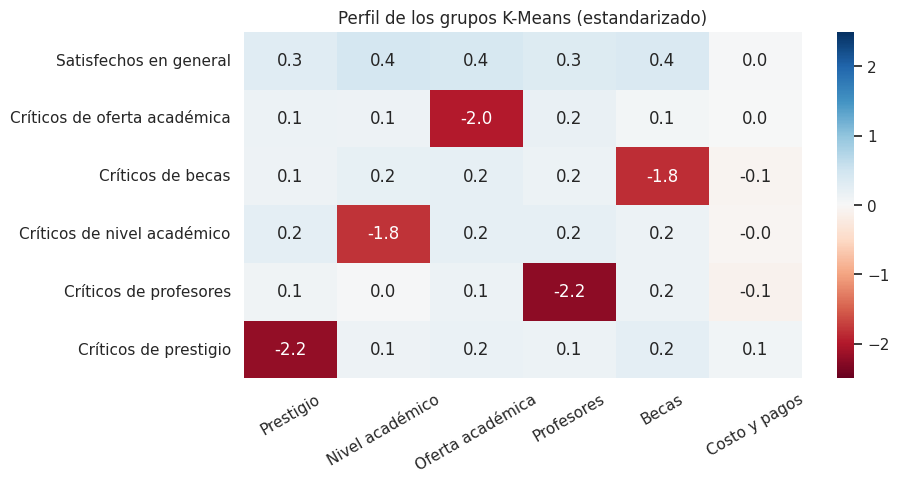

In [43]:
# Mapa de calor: azul = arriba del promedio, rojo = abajo
plt.figure(figsize=(9, 4.5))
sns.heatmap(perfil_km.rename(index=nombres_km).loc[orden], annot=True, fmt='.1f',
            cmap='RdBu', center=0, vmin=-2.5, vmax=2.5)
plt.title('Perfil de los grupos K-Means (estandarizado)')
plt.xticks(rotation=30)
plt.show()

### 8.3 Silueta de cada alumno

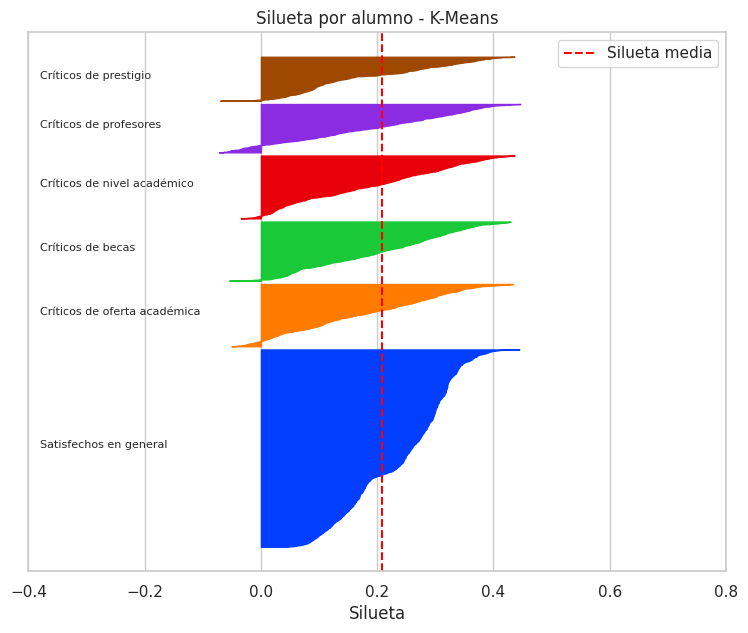

In [44]:
from sklearn.metrics import silhouette_samples

# silhouette_samples da la silueta de cada alumno (silhouette_score da el promedio)
cluster_results['Silueta'] = silhouette_samples(X_escalado, etiquetas_km)

fig, ax = plt.subplots(figsize=(9, 7))
y = 10
for grupo in orden:
    valores = cluster_results.loc[cluster_results['Grupo K-Means'] == grupo, 'Silueta'].sort_values().tolist()
    ax.fill_betweenx(range(y, y + len(valores)), 0, valores, color=colores[grupo])
    ax.text(-0.38, y + len(valores) / 2, grupo, fontsize=8)
    y = y + len(valores) + 40
ax.axvline(cluster_results['Silueta'].mean(), color='red', linestyle='--', label='Silueta media')
ax.set(title='Silueta por alumno - K-Means', xlabel='Silueta', xlim=(-0.4, 0.8))
ax.set_yticks([])
ax.legend()
plt.show()

In [45]:
# Silueta promedio y % de alumnos con silueta negativa en cada grupo
resumen_silueta = pd.DataFrame({
    'Silueta media': cluster_results.groupby('Grupo K-Means')['Silueta'].mean(),
    '% negativa': (cluster_results['Silueta'] < 0).groupby(cluster_results['Grupo K-Means']).mean() * 100
}).loc[orden].round(3)
resumen_silueta

,Silueta media,% negativa
Grupo K-Means,,
Satisfechos en general,0.241,0.000
Críticos de oferta académica,0.172,8.629
Críticos de becas,0.204,2.400
Críticos de nivel académico,0.184,4.277
Críticos de profesores,0.184,15.196
Críticos de prestigio,0.182,2.509


### 8.4 Gráfica de dispersión en 2D

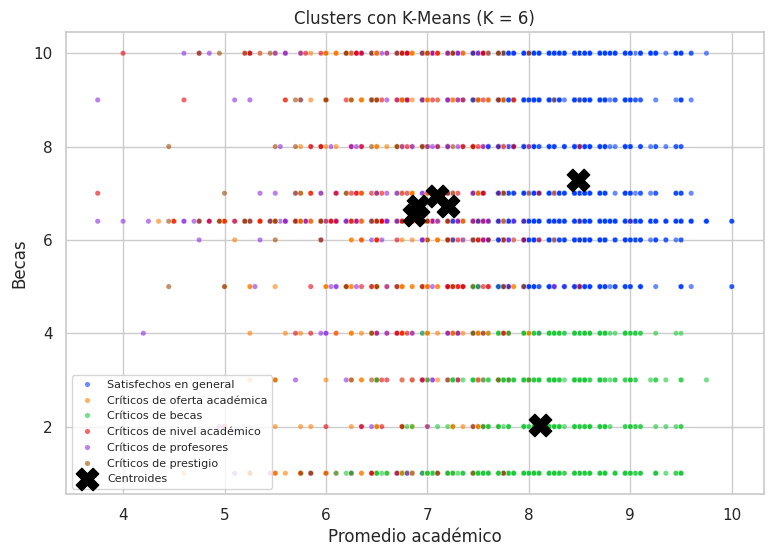

In [46]:
# Centroides en las mismas dos dimensiones de la gráfica
centroides['Promedio académico'] = centroides[academicas].mean(axis=1)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=cluster_results, x='Promedio académico', y='Becas', hue='Grupo K-Means',
                hue_order=orden, palette=colores, s=15, alpha=0.6)
plt.scatter(centroides['Promedio académico'], centroides['Becas'], marker='X', s=260, c='black', label='Centroides')
plt.title('Clusters con K-Means (K = 6)')
plt.legend(fontsize=8)
plt.show()

#### Misma gráfica con los puntos dispersos

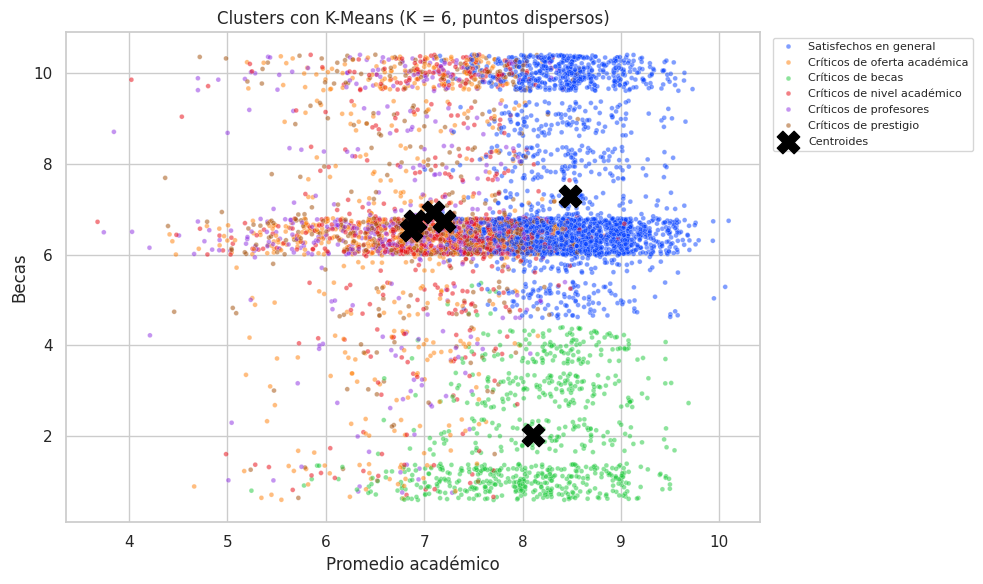

In [47]:
# Becas solo tiene valores enteros (y el 6.4 de relleno), por eso los puntos salen en líneas.
# Les sumo un desplazamiento pequeño solo para la gráfica, para que se vean dispersos
n = len(cluster_results)
puntos_2d = cluster_results[['Promedio académico', 'Becas', 'Grupo K-Means']].copy()
desplazamiento_x = pd.Series(range(n)).sample(frac=1, random_state=10).values / n - 0.5
desplazamiento_y = pd.Series(range(n)).sample(frac=1, random_state=20).values / n - 0.5
puntos_2d['Promedio académico'] = puntos_2d['Promedio académico'] + desplazamiento_x * 0.2
puntos_2d['Becas'] = puntos_2d['Becas'] + desplazamiento_y * 0.8

plt.figure(figsize=(10, 6))
sns.scatterplot(data=puntos_2d, x='Promedio académico', y='Becas', hue='Grupo K-Means',
                hue_order=orden, palette=colores, s=12, alpha=0.5)
plt.scatter(centroides['Promedio académico'], centroides['Becas'], marker='X', s=260, c='black', label='Centroides')
plt.title('Clusters con K-Means (K = 6, puntos dispersos)')
plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8.5 Gráfica de dispersión en 3D

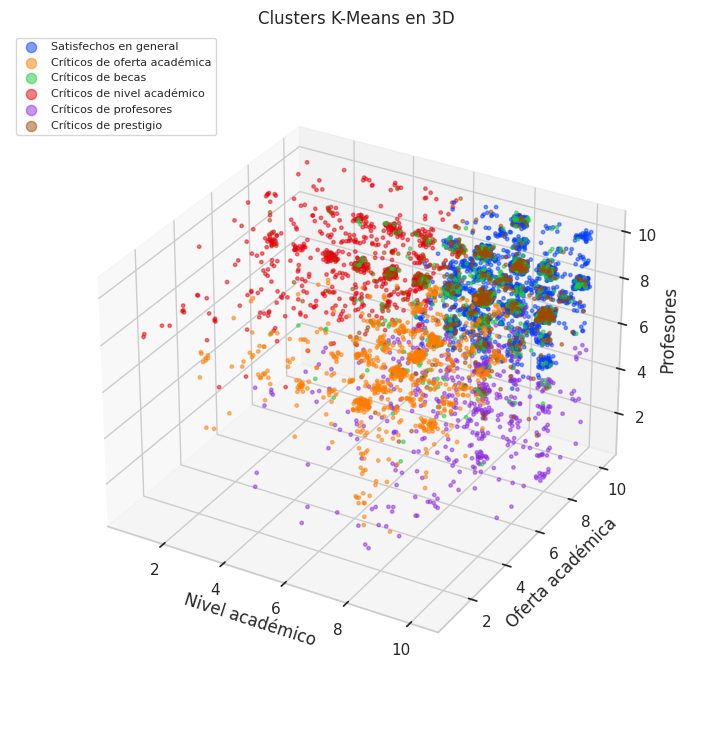

In [48]:
# 3D con tres variables académicas
ejes_3d = ['Nivel académico', 'Oferta académica', 'Profesores']

# Muchos alumnos tienen la misma calificación y los puntos se enciman.
# Les sumo un desplazamiento pequeño (entre -0.2 y 0.2) solo para la gráfica
n = len(cluster_results)
puntos_3d = cluster_results[ejes_3d].copy()
for i, columna in enumerate(ejes_3d):
    desplazamiento = pd.Series(range(n)).sample(frac=1, random_state=i).values / n - 0.5
    puntos_3d[columna] = puntos_3d[columna] + desplazamiento * 0.4

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect(None, zoom=0.85)  # para que se vea el nombre del eje z
for grupo in orden:
    filtro = cluster_results['Grupo K-Means'] == grupo
    ax.scatter(puntos_3d.loc[filtro, ejes_3d[0]], puntos_3d.loc[filtro, ejes_3d[1]], puntos_3d.loc[filtro, ejes_3d[2]],
               s=6, alpha=0.5, color=colores[grupo], label=grupo)
ax.set_xlabel(ejes_3d[0])
ax.set_ylabel(ejes_3d[1])
ax.set_zlabel(ejes_3d[2])
ax.set_title('Clusters K-Means en 3D')
ax.legend(fontsize=8, markerscale=3, loc='upper left')
plt.show()

### 8.6 Boxplots por grupo

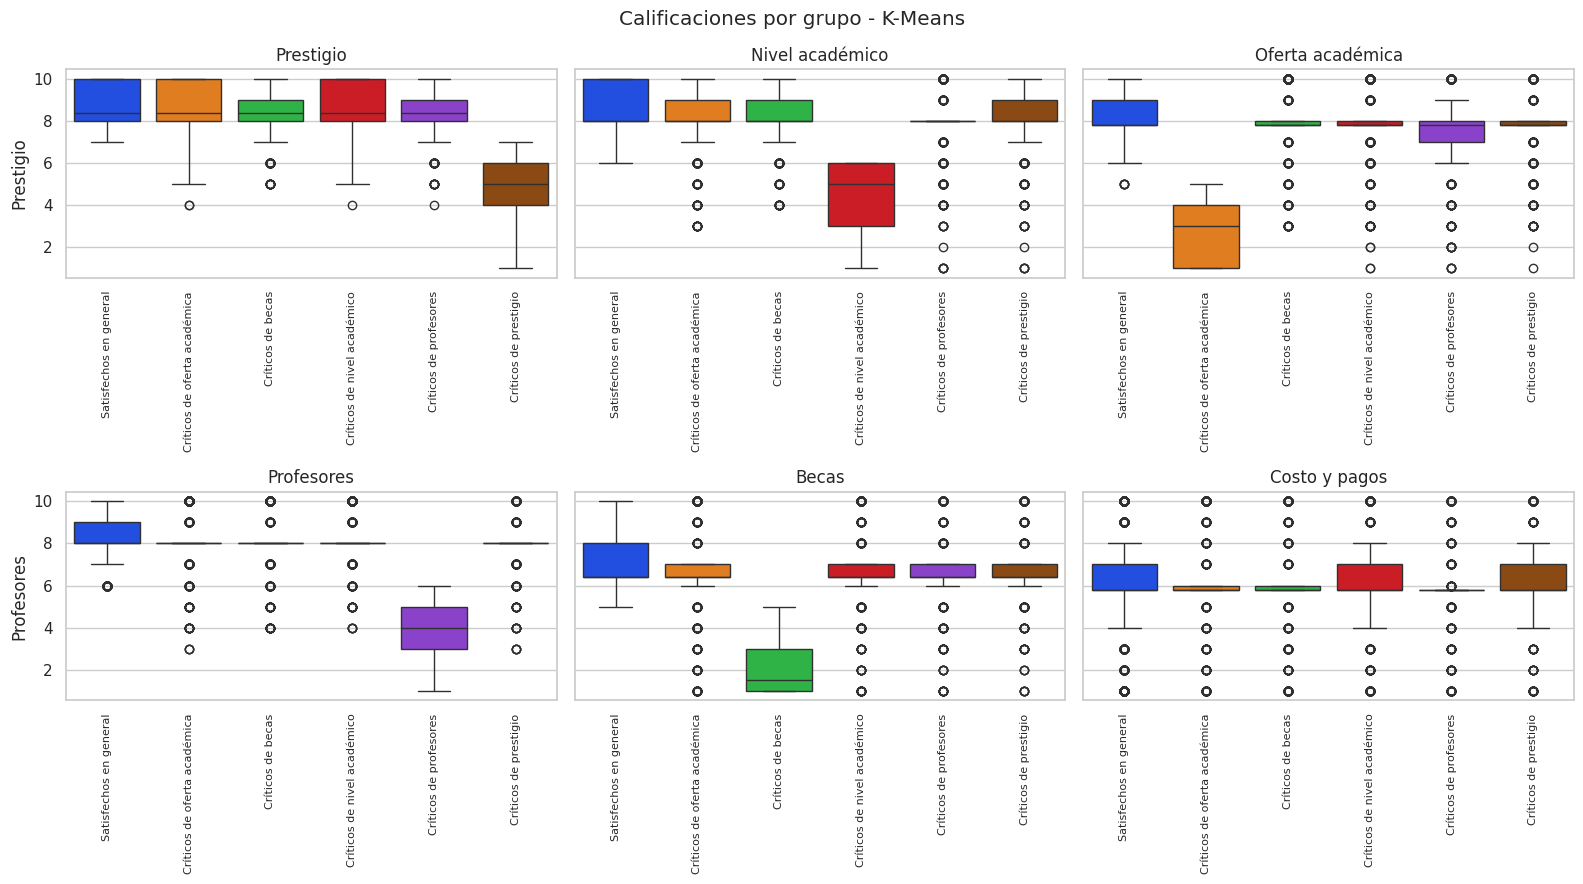

In [49]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for eje, variable in zip(ejes.flat, variables):
    sns.boxplot(data=cluster_results, x='Grupo K-Means', y=variable, order=orden,
                hue='Grupo K-Means', palette=colores, legend=False, ax=eje)
    eje.set_title(variable)
    eje.set_xlabel('')
    eje.tick_params(axis='x', rotation=90, labelsize=8)
plt.suptitle('Calificaciones por grupo - K-Means')
plt.tight_layout()
plt.show()

### 8.7 Comprobación con 5 variables (sin costo)

In [50]:
# Pruebo quitando Costo y pagos, que es la variable que no define a ningún grupo
variables_5 = ['Prestigio', 'Nivel académico', 'Oferta académica', 'Profesores', 'Becas']
X_escalado_5 = StandardScaler().fit_transform(datos[variables_5])

silueta_5 = []
for k in range(2, 9):
    etiquetas = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_escalado_5)
    silueta_5.append(silhouette_score(X_escalado_5, etiquetas))
tabla_5 = pd.DataFrame({'K': range(2, 9), 'Silueta 5 variables': silueta_5}).round(3)
display(tabla_5)

,K,Silueta 5 variables
0,2,0.238
1,3,0.236
2,4,0.236
3,5,0.236
4,6,0.265
5,7,0.226
6,8,0.223


In [51]:
# Modelo de 5 variables con K = 6 y mismos nombres de grupos
etiquetas_5 = KMeans(n_clusters=6, random_state=42, n_init=10).fit_predict(X_escalado_5)
perfil_5 = pd.DataFrame(X_escalado_5, columns=variables_5).groupby(etiquetas_5).mean()
nombres_5 = {}
for grupo in perfil_5.index:
    if perfil_5.loc[grupo].min() < -1:
        nombres_5[grupo] = 'Críticos de ' + perfil_5.loc[grupo].idxmin().lower()
    else:
        nombres_5[grupo] = 'Satisfechos en general'

grupo_5 = pd.Series(etiquetas_5).map(nombres_5)
print('Alumnos en el mismo grupo que con 6 variables:', round((grupo_5 == cluster_results['Grupo K-Means']).mean() * 100, 1), '%')

Alumnos en el mismo grupo que con 6 variables: 99.2 %


Con 5 variables también sale K = 6 y casi todos los alumnos quedan en el mismo grupo. El costo no cambia los grupos, pero lo dejo porque me permite ver que el costo es una queja de todos los grupos y no de uno solo.

## 9. Jerárquico vs. K-Means

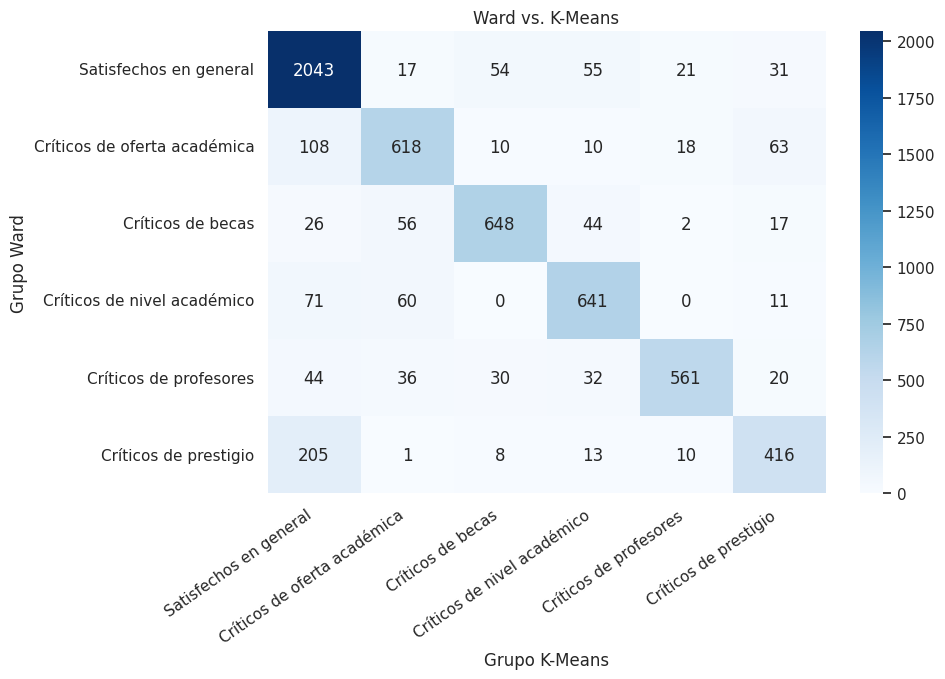

In [52]:
cruce = pd.crosstab(cluster_results['Grupo Ward'], cluster_results['Grupo K-Means']).loc[orden, orden]

plt.figure(figsize=(9, 6))
sns.heatmap(cruce, annot=True, fmt='d', cmap='Blues')
plt.title('Ward vs. K-Means')
plt.xlabel('Grupo K-Means')
plt.ylabel('Grupo Ward')
plt.xticks(rotation=35, ha='right')
plt.show()

In [53]:
print('Mismo grupo en los dos métodos:', round((cluster_results['Grupo Ward'] == cluster_results['Grupo K-Means']).mean() * 100, 1), '%')
print('Silueta Ward:', round(silhouette_score(X_escalado, data_labels), 3))
print('Silueta K-Means:', round(silhouette_score(X_escalado, etiquetas_km), 3))

Mismo grupo en los dos métodos: 82.1 %


Silueta Ward: 0.165


Silueta K-Means: 0.209


## 10. ¿Qué universidades califican mejor?

In [54]:
por_universidad = cluster_results.groupby('UNIVERSIDAD_EVALUADA_NACIONAL')[variables].mean()
por_universidad['Promedio general'] = por_universidad[variables].mean(axis=1)
por_universidad['Alumnos'] = cluster_results['UNIVERSIDAD_EVALUADA_NACIONAL'].value_counts()
por_universidad['% Satisfechos'] = pd.crosstab(cluster_results['UNIVERSIDAD_EVALUADA_NACIONAL'],
                                               cluster_results['Grupo K-Means'],
                                               normalize='index')['Satisfechos en general'] * 100

# Solo dejo universidades con al menos 50 alumnos
ranking = por_universidad[por_universidad['Alumnos'] >= 50].sort_values('Promedio general', ascending=False)
ranking.round(2)

,Prestigio,Nivel académico,Oferta académica,Profesores,Becas,Costo y pagos,Promedio general,Alumnos,% Satisfechos
UNIVERSIDAD_EVALUADA_NACIONAL,,,,,,,,,
UVM,8.36,7.94,7.38,7.91,6.34,6.15,7.34,453,45.92
UP,8.27,7.98,7.05,7.69,6.56,6.29,7.31,186,40.86
UNIVER,8.20,7.90,7.32,7.82,6.67,5.88,7.30,143,45.45
ITESM,8.18,7.64,7.33,7.76,6.49,6.29,7.28,502,40.04
OTRAS1,8.26,7.73,7.36,7.78,6.39,6.09,7.27,2791,42.31
UAD,8.26,7.97,6.96,7.82,6.43,6.15,7.27,130,35.38
UNID,8.42,7.95,7.16,7.66,6.12,6.22,7.25,155,43.23
UNIVA,8.19,7.84,7.15,7.96,6.41,5.90,7.24,195,42.56
ANÁHUAC,8.40,7.63,7.37,7.96,6.20,5.87,7.24,99,45.45


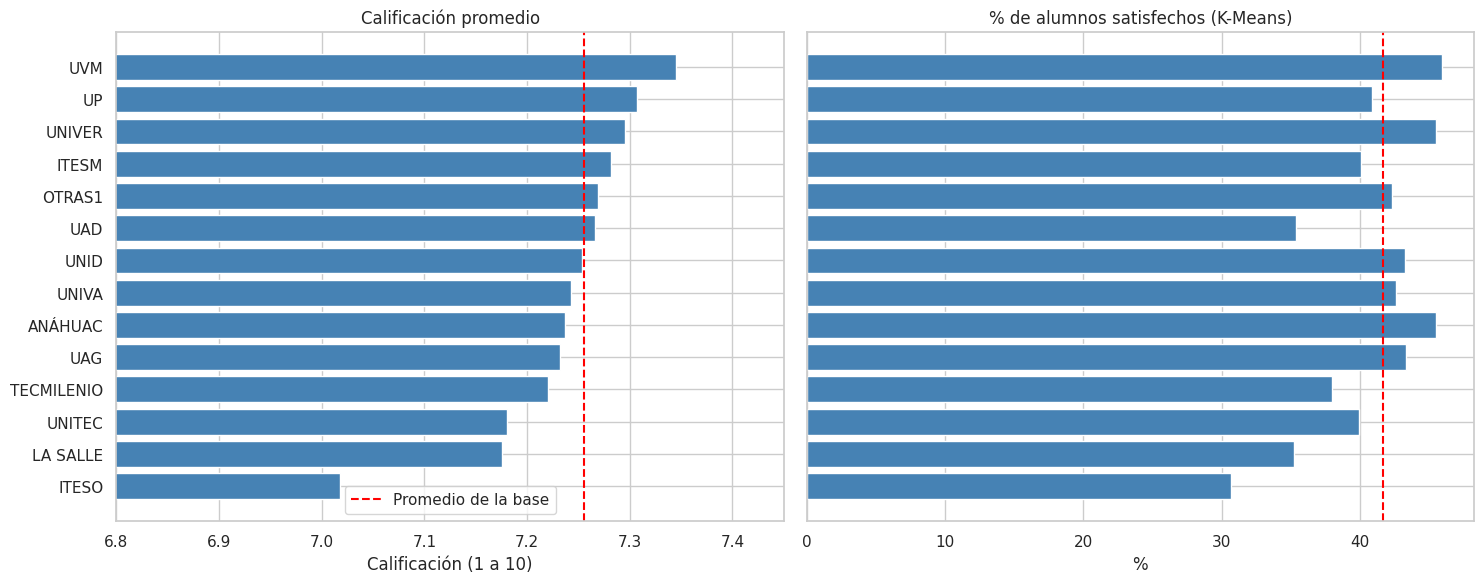

In [55]:
promedio_base = X.mean().mean()
satisfechos_base = (cluster_results['Grupo K-Means'] == 'Satisfechos en general').mean() * 100

fig, ejes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ejes[0].barh(ranking.index, ranking['Promedio general'], color='steelblue')
ejes[0].axvline(promedio_base, color='red', linestyle='--', label='Promedio de la base')
ejes[0].set(title='Calificación promedio', xlabel='Calificación (1 a 10)', xlim=(6.8, 7.45))
ejes[0].legend()
ejes[0].invert_yaxis()
ejes[1].barh(ranking.index, ranking['% Satisfechos'], color='steelblue')
ejes[1].axvline(satisfechos_base, color='red', linestyle='--')
ejes[1].set(title='% de alumnos satisfechos (K-Means)', xlabel='%')
plt.tight_layout()
plt.show()

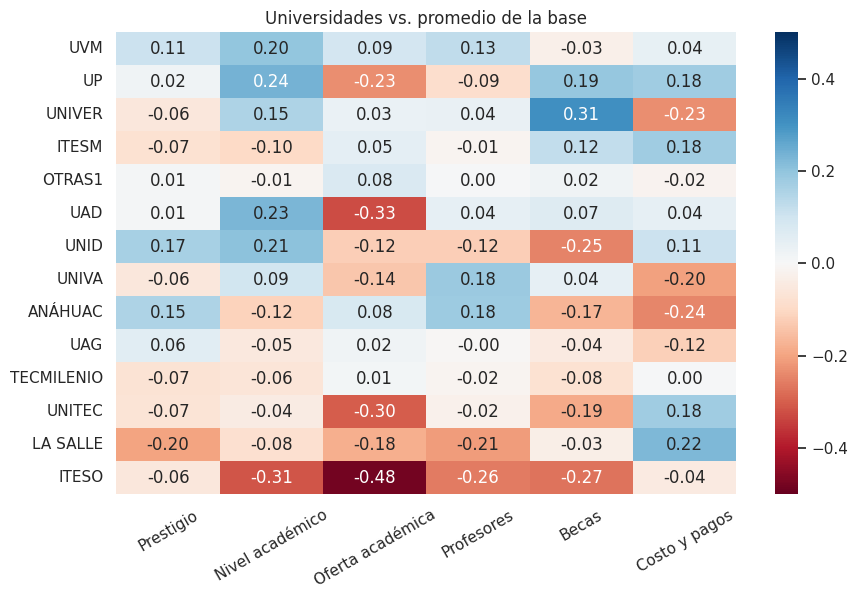

In [56]:
# En qué variable está arriba o abajo cada universidad
diferencias = ranking[variables] - X.mean()
plt.figure(figsize=(10, 6))
sns.heatmap(diferencias, annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-0.5, vmax=0.5)
plt.title('Universidades vs. promedio de la base')
plt.ylabel('')
plt.xticks(rotation=30)
plt.show()

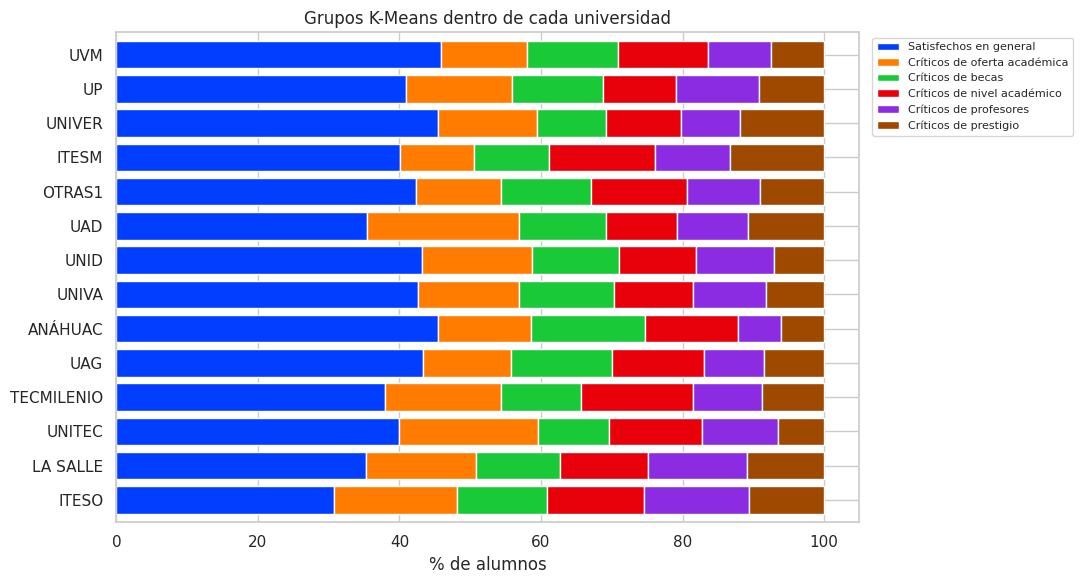

In [57]:
composicion = pd.crosstab(cluster_results['UNIVERSIDAD_EVALUADA_NACIONAL'], cluster_results['Grupo K-Means'],
                          normalize='index').loc[ranking.index, orden] * 100
composicion.plot(kind='barh', stacked=True, figsize=(11, 6), color=[colores[g] for g in orden], width=0.8)
plt.title('Grupos K-Means dentro de cada universidad')
plt.xlabel('% de alumnos')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Respuestas

**¿Cuántos clusters se ven?** 6. Lo dicen el dendrograma (salto más grande), la silueta de K-Means (más alta en K = 6) y el codo.

**¿Qué características tienen?**
- Satisfechos en general (41.6 %): califican todo arriba del promedio.
- Críticos de nivel académico (13.3 %): nivel académico ≈ 4.2.
- Críticos de oferta académica (13.1 %): oferta ≈ 2.9.
- Críticos de becas (12.5 %): becas ≈ 2.0.
- Críticos de profesores (10.2 %): profesores ≈ 3.8.
- Críticos de prestigio (9.3 %): prestigio ≈ 4.7.
- El costo no define ningún grupo: está bajo (≈ 6) en todos.

**Jerárquico vs. K-Means:** encuentran los mismos 6 grupos y coinciden en 82 % de los alumnos. K-Means separa mejor (silueta 0.209 contra 0.165). El jerárquico ayuda a decidir cuántos grupos hay con el dendrograma y siempre da lo mismo; K-Means da los centroides directo, es más rápido y puede clasificar alumnos nuevos.

**¿Qué universidades califican mejor?** UVM (7.34 y 45.9 % de satisfechos), UP (7.31) y UNIVER (7.30). Las más bajas son ITESO (7.02 y 30.7 % de satisfechos), La Salle y UNITEC (7.18). La diferencia entre la primera y la última es de solo 0.33 puntos.

**Conclusión:** casi la mitad de los alumnos está satisfecha y el resto tiene una sola queja concreta. Una universidad debería mandar un mensaje distinto a cada grupo según su queja.